# aav2 / aav5 -- does the MLP miss the NOISIEST true top-500 variants, or genuinely wrong ones?

`aav9.csv`'s `error` column turned out to be a useless constant (0.1 for every row), so the
earlier noise-vs-model-failure question (`AAV9_FJ_matrix_top500_check.ipynb`) could only be
answered indirectly, via the statistical SIGNATURE of regression-to-the-mean. `aav2.csv` and
`aav5.csv` are different: their `error` column is real and informative -- it correlates at
r=-0.87 (aav2) / r=-0.83 (aav5) with `log(plasmid read count)`, exactly the pattern expected of
a genuine per-variant uncertainty estimate (fewer reads -> less reliable `target` -> higher
`error`).

This notebook tests the hypothesis directly instead of inferring it indirectly: for the real
top-500 variants (by actual `target`) that a freshly-trained `ProfileMLP` **misses** from its
own top-500 predictions, is their `error` systematically HIGHER than for the ones it
**recovers**? If yes, that's direct evidence the model isn't randomly wrong about these
variants -- it's specifically failing on the ones whose measured `target` was itself the least
trustworthy to begin with (i.e. variants that likely got a lucky high read draw rather than a
genuinely high enrichment).

Run on both `aav2` and `aav5` (not `aav9`, which lacks usable `error`).


### Setup

In [7]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))
sys.path.insert(0, os.path.abspath("."))
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"  # must be set before jax initializes

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from sklearn.model_selection import train_test_split

from analysisV1 import AA_LABELS, pearson

import jax
import jax.numpy as jnp
from flax import nnx
from typing import Optional
import optax
from tqdm.auto import tqdm

print(f"JAX backend: {jax.default_backend()} -- devices: {jax.devices()}")

num_positions   = 7
num_amino_acids = len(AA_LABELS)
assert num_amino_acids == 20


JAX backend: gpu -- devices: [CudaDevice(id=0)]


### Model + training utilities

Same `ProfileMLP` architecture/training recipe used throughout this project's other AAV notebooks (`AAV_MLP_weights_recovery.ipynb`, `AAV9_FJ_matrix_top500_check.ipynb`).

In [8]:
class ProfileMLP(nnx.Module):
    """MLP over the one-hot encoded per-position sequence (L=7 x A=20 -> 140 indicator
    features) -> scalar predicted log enrichment."""

    def __init__(self, input_dim: int, hidden_dims: tuple[int, int] = (128, 64),
                 dropout_rate: float = 0.1, *, rngs: nnx.Rngs):
        h1, h2 = hidden_dims
        self.linear1    = nnx.Linear(input_dim, h1, rngs=rngs)
        self.batchnorm1 = nnx.BatchNorm(h1, use_running_average=False, rngs=rngs)
        self.dropout1   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear2    = nnx.Linear(h1, h2, rngs=rngs)
        self.batchnorm2 = nnx.BatchNorm(h2, use_running_average=False, rngs=rngs)
        self.dropout2   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear3    = nnx.Linear(h2, 1, rngs=rngs)

    def __call__(self, x: jax.Array, *, train: bool, rngs: Optional[nnx.Rngs] = None) -> jax.Array:
        x = self.linear1(x)
        x = self.batchnorm1(x, use_running_average=not train)
        x = self.dropout1(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        x = self.linear2(x)
        x = self.batchnorm2(x, use_running_average=not train)
        x = self.dropout2(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        return self.linear3(x).squeeze(-1)


@nnx.jit
def train_step(model, optimizer, x, y, rngs):
    def loss_fn(model, rngs):
        y_pred = model(x, train=True, rngs=rngs)
        return jnp.mean((y_pred - y) ** 2)
    loss, grads = nnx.value_and_grad(loss_fn)(model, rngs)
    optimizer.update(model, grads)
    return loss


@nnx.jit
def eval_step(model, x, y):
    y_pred = model(x, train=False)
    return jnp.mean((y_pred - y) ** 2)


@nnx.scan(in_axes=(nnx.Carry, 0, 0), out_axes=(nnx.Carry, 0))
def train_epoch_scan(carry, xb, yb):
    model, optimizer, rngs = carry
    loss = train_step(model, optimizer, xb, yb, rngs)
    return (model, optimizer, rngs), loss


def train_profile_mlp(X_train, y_train, X_val, y_val, hidden_dims=(128, 64),
                       dropout_rate=0.1, epochs=300, batch_size=256,
                       peak_lr=1e-3, final_lr=1e-5, weight_decay=0,
                       patience=20, seed=0, verbose=True):
    rngs  = nnx.Rngs(seed)
    model = ProfileMLP(input_dim=X_train.shape[1], hidden_dims=hidden_dims,
                        dropout_rate=dropout_rate, rngs=rngs)

    n_train         = X_train.shape[0]
    steps_per_epoch = max(n_train // batch_size, 1)
    total_steps     = steps_per_epoch * epochs

    lr_schedule_fn = optax.warmup_cosine_decay_schedule(
        init_value=0., peak_value=peak_lr,
        warmup_steps=int(total_steps * 0.1),
        decay_steps=int(total_steps * 0.9),
        end_value=final_lr,
    )
    optimizer = nnx.Optimizer(
        model, optax.adamw(learning_rate=lr_schedule_fn, weight_decay=weight_decay), wrt=nnx.Param
    )

    X_train, y_train = jnp.asarray(X_train), jnp.asarray(y_train)
    X_val,   y_val   = jnp.asarray(X_val),   jnp.asarray(y_val)

    shuffle_key = jax.random.key(seed)
    best_val, best_state, bad_epochs = float("inf"), None, 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in tqdm(range(epochs), desc="Training ProfileMLP", disable=not verbose):
        shuffle_key, perm_key = jax.random.split(shuffle_key)
        perm      = jax.random.permutation(perm_key, n_train)
        batch_idx = perm[: steps_per_epoch * batch_size].reshape(steps_per_epoch, batch_size)

        (model, optimizer, rngs), step_losses = train_epoch_scan(
            (model, optimizer, rngs), X_train[batch_idx], y_train[batch_idx]
        )
        train_loss = float(jnp.mean(step_losses))
        val_loss   = float(eval_step(model, X_val, y_val))

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val - 1e-5:
            best_val, bad_epochs = val_loss, 0
            best_state = nnx.state(model)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch} (best val MSE={best_val:.4f})")
                break

    nnx.update(model, best_state)
    return model, history


def split_train_val(X, y, val_frac=0.15, seed=0):
    rng   = np.random.default_rng(seed)
    idx   = rng.permutation(len(X))
    n_val = int(len(X) * val_frac)
    val_idx, train_idx = idx[:n_val], idx[n_val:]
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]


@nnx.jit
def predict_log_enrichment(model, x):
    return model(x, train=False)


<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
The core population used throughout this notebook: for EACH serotype separately, <code>run_dataset()</code> splits that serotype's real CSV in half (<code>idx_test</code>, <code>test_size=0.5</code>, real sequences only) and takes the top <code>top_k=500</code> of the held-out half by real <code>target</code> (<code>top_target_set</code>) vs. by a freshly-trained <code>ProfileMLP</code>'s predicted score (<code>top_pred_set</code>) — "recovered" = in both sets, "missed" = a real top-500 sequence the model's own top-500 didn't catch. This is a fresh 50/50 split computed independently per serotype in this notebook (same recipe — <code>test_size=0.5</code>, <code>seed=0</code> — but not the same Python objects as the analogous split in <code>AAV2_profile_model.ipynb</code> / <code>AAV5_profile_model.ipynb</code>).
</div>

### Per-dataset pipeline

In [9]:
def load_dataset(name):
    df = pd.read_csv(f"{name}.csv")
    lut = np.zeros(256, dtype=np.int64)
    for i, aa in enumerate(AA_LABELS):
        lut[ord(aa)] = i
    seq_bytes  = np.frombuffer("".join(df["sequence"]).encode("ascii"), dtype=np.uint8)
    seq_matrix = lut[seq_bytes].reshape(len(df), num_positions)
    target = df["target"].to_numpy()
    error  = df["error"].to_numpy()
    seq_oh = np.eye(num_amino_acids, dtype=np.float32)[seq_matrix].reshape(len(df), -1)
    return df, seq_matrix, target, error, seq_oh


def run_dataset(name, top_k=500, batch_size=256, seed=0):
    print(f"\n{'=' * 70}\n{name}\n{'=' * 70}")

    df, seq_matrix, target, error, seq_oh = load_dataset(name)
    print(f"{len(df):,} real {name} variants   error: mean={error.mean():.3f}  std={error.std():.3f}  "
          f"min={error.min():.4f}  max={error.max():.4f}")

    idx_train, idx_test = train_test_split(np.arange(len(df)), test_size=0.5, random_state=seed)
    y_train_full, y_test = target[idx_train], target[idx_test]
    X_train_full, X_test = seq_oh[idx_train], seq_oh[idx_test]
    error_test            = error[idx_test]
    Xtr, ytr, Xva, yva    = split_train_val(X_train_full, y_train_full, val_frac=0.15, seed=seed)
    print(f"train: {len(Xtr):,}  val: {len(Xva):,}  test: {len(X_test):,}")

    model, hist = train_profile_mlp(Xtr, ytr, Xva, yva, seed=seed, batch_size=batch_size)

    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.plot(hist["train_loss"], label="train MSE")
    ax.plot(hist["val_loss"], label="val MSE")
    ax.set_xlabel("epoch"); ax.set_ylabel("MSE (log enrichment)"); ax.set_title(f"{name}: ProfileMLP training curve")
    ax.legend(); ax.grid(True, linestyle="--", alpha=0.4)
    fig.tight_layout(); plt.show()

    pred_test = np.asarray(predict_log_enrichment(model, jnp.asarray(X_test)))
    r_test    = pearson(y_test, pred_test)
    print(f"Held-out test set ({len(y_test):,} variants): Pearson r(target, predicted) = {r_test:.4f}")

    top_target_set = set(np.argsort(-y_test)[:top_k].tolist())
    top_pred_set   = set(np.argsort(-pred_test)[:top_k].tolist())
    recovered_idx  = np.array(sorted(top_target_set & top_pred_set))
    missed_idx     = np.array(sorted(top_target_set - top_pred_set))

    error_recovered = error_test[recovered_idx]
    error_missed    = error_test[missed_idx]

    stat, p = mannwhitneyu(error_missed, error_recovered, alternative="greater")
    print(f"\nTop-{top_k} by real target: {len(recovered_idx)}/{top_k} recovered by the model's own "
          f"top-{top_k}, {len(missed_idx)}/{top_k} missed")
    print(f"error (missed):    median={np.median(error_missed):.4f}   mean={error_missed.mean():.4f}")
    print(f"error (recovered): median={np.median(error_recovered):.4f}   mean={error_recovered.mean():.4f}")
    print(f"Mann-Whitney U test (H1: missed has HIGHER error than recovered): U={stat:.1f}   p={p:.3e}")

    fig, ax = plt.subplots(figsize=(6, 5.5))
    bp = ax.boxplot([error_missed, error_recovered],
                     tick_labels=[f"Missed by model\n({len(error_missed)})", f"Recovered by model\n({len(error_recovered)})"],
                     showmeans=True, patch_artist=True)
    bp["boxes"][0].set_facecolor("steelblue")
    bp["boxes"][1].set_facecolor("forestgreen")
    ax.set_ylabel("error (per-variant measurement uncertainty)")
    ax.set_title(f"{name}: is the model missing the NOISIEST true top-{top_k} variants?\nMann-Whitney p={p:.2e}")
    fig.tight_layout(); plt.show()

    rng                = np.random.default_rng(seed)
    random_idx         = rng.choice(len(y_test), size=top_k, replace=False)
    error_top500_all   = error_test[np.array(sorted(top_target_set))]
    error_random       = error_test[random_idx]
    stat2, p2          = mannwhitneyu(error_top500_all, error_random, alternative="greater")
    print(f"\nAs a sanity check -- is the real top-{top_k} group (as a whole) noisier than a random "
          f"{top_k}? median error top-{top_k}={np.median(error_top500_all):.4f}   "
          f"median error random={np.median(error_random):.4f}   Mann-Whitney p={p2:.3e}")

    result = dict(name=name, n=len(df), r_test=r_test,
                  n_recovered=len(recovered_idx), n_missed=len(missed_idx),
                  median_error_missed=float(np.median(error_missed)),
                  median_error_recovered=float(np.median(error_recovered)),
                  mw_p_missed_vs_recovered=float(p),
                  median_error_top500=float(np.median(error_top500_all)),
                  median_error_random=float(np.median(error_random)),
                  mw_p_top500_vs_random=float(p2))
    # extras: raw arrays needed for follow-up analyses (e.g. the vector1-vs-vector2
    # replicate-disagreement check below) without having to retrain the model again.
    extras = dict(idx_test=idx_test, missed_idx=missed_idx, recovered_idx=recovered_idx,
                  y_test=y_test, pred_test=pred_test, error_test=error_test)
    return result, extras


<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
Same top-500-in-<code>idx_test</code> population described just above, now applied to <code>aav2.csv</code> specifically (53,382 real sequences; <code>idx_test</code> is the held-out half of them).
</div>

### aav2


aav2
53,382 real aav2 variants   error: mean=1.099  std=0.574  min=0.0010  max=1.6667
train: 22,688  val: 4,003  test: 26,691


Training ProfileMLP:  12%|█▏        | 37/300 [00:01<00:10, 24.32it/s]

Early stopping at epoch 37 (best val MSE=3.1251)


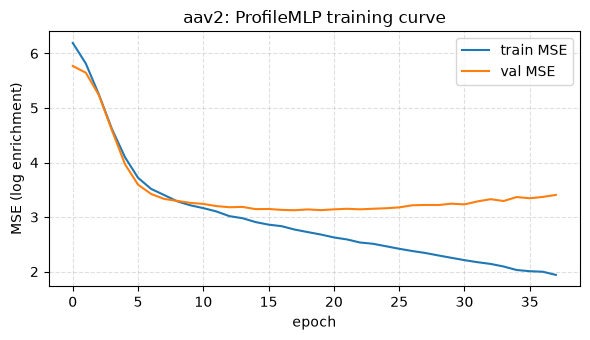

Held-out test set (26,691 variants): Pearson r(target, predicted) = 0.4623

Top-500 by real target: 22/500 recovered by the model's own top-500, 478/500 missed
error (missed):    median=0.0975   mean=0.3394
error (recovered): median=0.0854   mean=0.4033
Mann-Whitney U test (H1: missed has HIGHER error than recovered): U=5408.5   p=4.105e-01


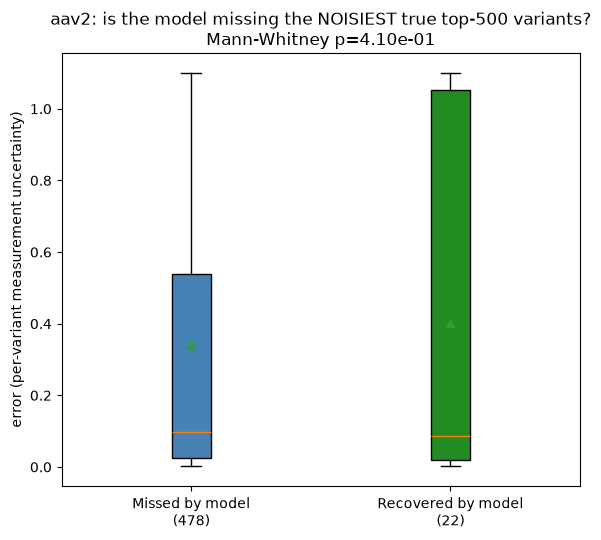


As a sanity check -- is the real top-500 group (as a whole) noisier than a random 500? median error top-500=0.0975   median error random=1.3333   Mann-Whitney p=1.000e+00


In [10]:
result_aav2, extras_aav2 = run_dataset("aav2")


<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
Same top-500-in-<code>idx_test</code> population, now applied to <code>aav5.csv</code> specifically (737,587 real sequences, the largest of the three serotypes; <code>idx_test</code> is the held-out half of them).
</div>

### aav5

737,587 variants -- large enough that a bigger batch size (2048 instead of 256) keeps training time reasonable without changing the recipe.


aav5
737,587 real aav5 variants   error: mean=1.321  std=0.513  min=0.0014  max=2.0000
train: 313,475  val: 55,318  test: 368,794


Training ProfileMLP:  13%|█▎        | 40/300 [00:02<00:16, 15.36it/s]


Early stopping at epoch 40 (best val MSE=7.2097)


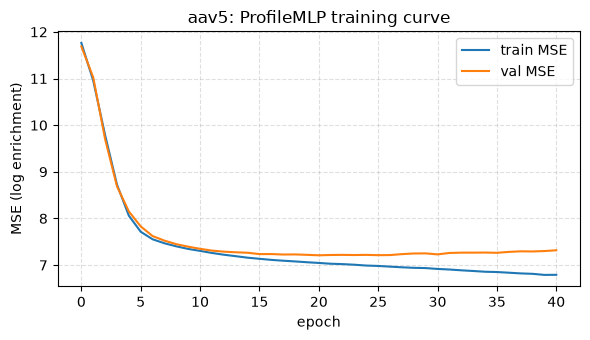

Held-out test set (368,794 variants): Pearson r(target, predicted) = 0.3890

Top-500 by real target: 5/500 recovered by the model's own top-500, 495/500 missed
error (missed):    median=0.0498   mean=0.2299
error (recovered): median=0.0083   mean=0.2228
Mann-Whitney U test (H1: missed has HIGHER error than recovered): U=1663.5   p=9.280e-02


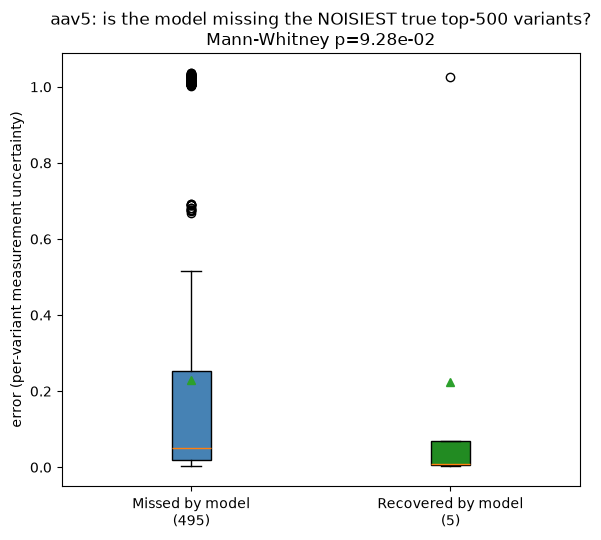


As a sanity check -- is the real top-500 group (as a whole) noisier than a random 500? median error top-500=0.0495   median error random=1.5000   Mann-Whitney p=1.000e+00


In [11]:
result_aav5, extras_aav5 = run_dataset("aav5", batch_size=2048)


## Summary across both datasets

In [12]:
summary = pd.DataFrame([result_aav2, result_aav5]).set_index("name")
summary


,n,r_test,n_recovered,n_missed,median_error_missed,median_error_recovered,mw_p_missed_vs_recovered,median_error_top500,median_error_random,mw_p_top500_vs_random
name,,,,,,,,,,
aav2,53382,0.462272,22,478,0.097498,0.085372,0.410451,0.097498,1.333332,1.0
aav5,737587,0.389038,5,495,0.049818,0.008275,0.092804,0.049490,1.500000,1.0


<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
Two populations appear from here on: (1) the same real top-500-by-<code>target</code>-within-<code>idx_test</code> from the sections above (<code>top_target_set</code>), and (2) a NEW <code>random_idx</code> — 500 real sequences chosen UNIFORMLY AT RANDOM from <code>idx_test</code> (not ranked, not "top" of anything), used purely as a naive baseline for the error comparison. Both are real, held-out sequences; neither is the global brute-force random background (millions of synthetic sequences over the full 20^7 space) used elsewhere in this project.
</div>

## Important caveat: `error` is NOT monotonically related to `target`

The "sanity check" above (real top-500 vs. a random 500) shows a huge gap in median `error` --
but before reading that as "the top-500 are reliable, so they're real", it's worth checking
*why*. `error` turns out to have a **U-shaped relationship with `target`**, not a simple
"extreme target -> unreliable" one: splitting each dataset into target deciles, `error` is
LOWEST at BOTH extremes (very negative AND very positive `target`) and HIGHEST in the middle,
near a null effect. This is a standard, expected feature of enrichment-ratio assays -- a
variant that's clearly very good or very bad accumulates enough distinguishing reads to be
called confidently either way, while a near-zero effect is the hardest to pin down. So the
random-500 baseline (drawn mostly from the noisy middle of the distribution) was never a fair
comparison -- the huge gap it showed is mostly this U-shape, not evidence that the top-500 are
"real". The `missed` vs. `recovered` comparison above is the fairer test: both groups are
already restricted to the same extreme (top-500) tail, so they sit on the same side of the
U-shape and aren't confounded by it the same way.


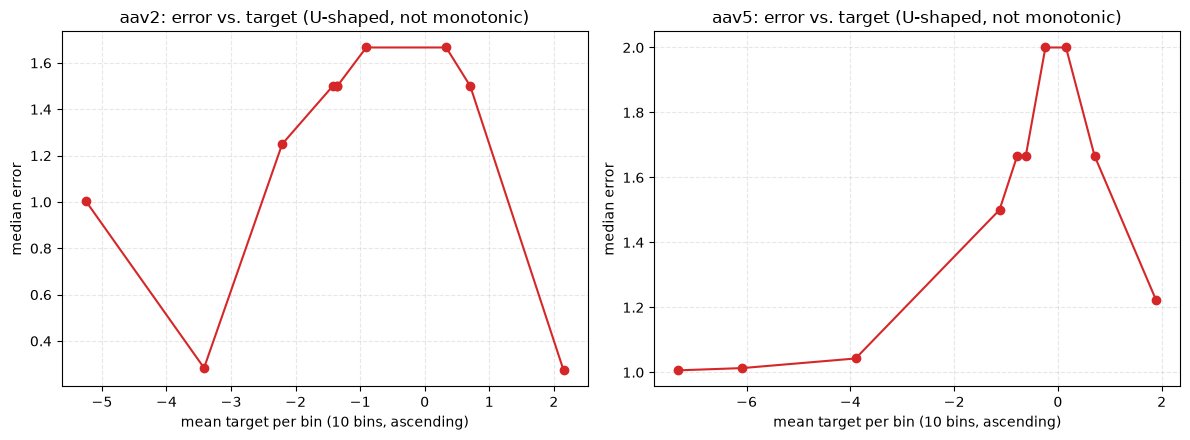

In [13]:
n_bins = 10
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, name in zip(axes, ["aav2", "aav5"]):
    df_i = pd.read_csv(f"{name}.csv")
    target_i = df_i["target"].to_numpy()
    error_i  = df_i["error"].to_numpy()
    order   = np.argsort(target_i)
    bins    = np.array_split(order, n_bins)
    bin_tgt = np.array([target_i[b].mean()   for b in bins])
    bin_err = np.array([np.median(error_i[b]) for b in bins])
    ax.plot(bin_tgt, bin_err, "o-", color="tab:red")
    ax.set_xlabel(f"mean target per bin ({n_bins} bins, ascending)")
    ax.set_ylabel("median error")
    ax.set_title(f"{name}: error vs. target (U-shaped, not monotonic)")
    ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout(); plt.show()


<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
Reused population: <code>missed_idx</code>/<code>recovered_idx</code> below are still the aav5 top-500-by-<code>target</code>-within-<code>idx_test</code> population defined earlier in this notebook — the same 500 sequences, now checked against a different noise proxy (<code>vector1</code>/<code>vector2</code> replicate disagreement) instead of the <code>error</code> column.
</div>

## `error` only captures TECHNICAL (read-count) noise -- not biological noise

Fair point: `error` is derived from read counts (it correlates at r=-0.87/-0.83 with
`log(plasmid count)`) -- it quantifies **sampling/counting uncertainty**: given how many times
we happened to sequence this exact variant, how precisely do we know its enrichment ratio? What
it CANNOT see is **biological/experimental noise**: run-to-run variability in transfection
efficiency, cell health, pipetting, packaging efficiency, well position, etc. -- variability in
the TRUE underlying outcome, not in how precisely we counted it afterwards. A variant can be
sequenced extremely deeply (tiny `error`) and STILL have its one measured `target` be a fluke of
that particular experimental run. `error` structurally cannot tell the two apart.

The standard fix for that is a genuine second, independent measurement -- not a confidence
interval on the first one. `aav5.csv` happens to have exactly that: `vector1` and `vector2` are
two separate output-pool read counts from the same `plasmid` input pool. The `target` column
(verified earlier) is built purely from `vector2`; `vector1` was never used. Reconstructing
`target1 = log2(vector1_norm / plasmid_norm)` gives a second, independent enrichment estimate
for the same variants -- their **disagreement** (`|target1 - target2|`) reflects the TOTAL noise
(biological AND technical combined) affecting each variant's measured `target`, which is exactly
the kind of signal you're asking for.

**Caveat carried over from earlier in this conversation, still unresolved**: nothing in the data
confirms whether `vector1`/`vector2` are truly independent parallel replicates (in which case
this disagreement is a clean noise estimate) or sequential rounds/steps (in which case some of
the disagreement reflects real round-to-round selection dynamics, not pure noise) -- worth
confirming with whoever produced this file. Either way it's a strictly better proxy than `error`
alone, since it isn't a mechanical function of a single read count.

This can only be run on `aav5` -- `aav2` has no second output-pool column, so the
biological-noise hypothesis can't be tested there with the data currently in this repo.


aav5: corr(target1, target2) across all 737,587 variants = 0.7541  (the empirical noise ceiling -- even two measurements of the SAME variant only agree this much)
|target1 - target2|: median=0.023   mean=0.947

aav5 -- replicate disagreement (biological + technical noise combined), missed vs. recovered:
disagreement (missed):    median=7.8457   mean=7.6080
disagreement (recovered): median=8.5224   mean=7.7042
Mann-Whitney U test (H1: missed has HIGHER replicate disagreement than recovered): U=1045.5   p=7.254e-01


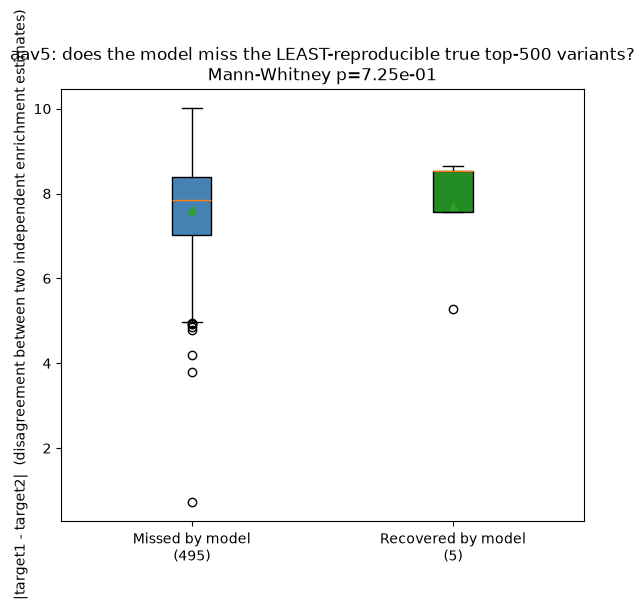

In [14]:
df5 = pd.read_csv("aav5.csv")
target1 = np.log2(df5["vector1_norm"].to_numpy() / df5["plasmid_norm"].to_numpy())
target2 = np.log2(df5["vector2_norm"].to_numpy() / df5["plasmid_norm"].to_numpy())
assert np.allclose(target2, df5["target"].to_numpy(), atol=1e-8), "target2 should reproduce the official target column"

disagreement = np.abs(target1 - target2)
r_replicates = pearson(target1, target2)
print(f"aav5: corr(target1, target2) across all {len(df5):,} variants = {r_replicates:.4f}  "
      f"(the empirical noise ceiling -- even two measurements of the SAME variant only agree this much)")
print(f"|target1 - target2|: median={np.median(disagreement):.3f}   mean={disagreement.mean():.3f}")

idx_test_g     = extras_aav5["idx_test"]
missed_local   = extras_aav5["missed_idx"]
recovered_local = extras_aav5["recovered_idx"]
missed_global    = idx_test_g[missed_local]
recovered_global = idx_test_g[recovered_local]

disagreement_missed    = disagreement[missed_global]
disagreement_recovered = disagreement[recovered_global]

stat3, p3 = mannwhitneyu(disagreement_missed, disagreement_recovered, alternative="greater")
print(f"\naav5 -- replicate disagreement (biological + technical noise combined), missed vs. recovered:")
print(f"disagreement (missed):    median={np.median(disagreement_missed):.4f}   mean={disagreement_missed.mean():.4f}")
print(f"disagreement (recovered): median={np.median(disagreement_recovered):.4f}   mean={disagreement_recovered.mean():.4f}")
print(f"Mann-Whitney U test (H1: missed has HIGHER replicate disagreement than recovered): "
      f"U={stat3:.1f}   p={p3:.3e}")

fig, ax = plt.subplots(figsize=(6, 5.5))
bp = ax.boxplot([disagreement_missed, disagreement_recovered],
                 tick_labels=[f"Missed by model\n({len(disagreement_missed)})",
                               f"Recovered by model\n({len(disagreement_recovered)})"],
                 showmeans=True, patch_artist=True)
bp["boxes"][0].set_facecolor("steelblue")
bp["boxes"][1].set_facecolor("forestgreen")
ax.set_ylabel("|target1 - target2|  (disagreement between two independent enrichment estimates)")
ax.set_title(f"aav5: does the model miss the LEAST-reproducible true top-500 variants?\nMann-Whitney p={p3:.2e}")
fig.tight_layout(); plt.show()


<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
<b>A different population from the rest of this notebook:</b> <code>top500_by_target_idx</code> below is the top-500 of <code>aav5.csv</code> by real <code>target</code> computed over the <b>full dataset</b> (all 737,587 rows, train+test combined) — it is <b>not</b> restricted to <code>idx_test</code> and is <b>not</b> the same index set as the <code>top_target_set</code> / <code>missed_idx</code> / <code>recovered_idx</code> used everywhere above (those live in <code>idx_test</code>'s own ~368,793-row index space). Don't conflate the two "aav5 top-500"s in this notebook.
</div>

### Caveat resolved: `vector1`/`vector2` are almost certainly sequential rounds, not parallel replicates

The disagreement result above is suspicious: `|target1 - target2|` has median 0.023 across the
*whole* dataset, but median ~8 within the top-500 -- a ~350x jump specifically for the best
variants. That's not what independent-replicate noise looks like (noise wouldn't single out
exactly the top-500). Checking the RAW read counts behind `target1`/`target2` for the top-500
confirms why:


In [ ]:
top500_by_target_idx = np.argsort(-df5["target"].to_numpy())[:500]
v1_top500 = df5["vector1"].to_numpy()[top500_by_target_idx]
v2_top500 = df5["vector2"].to_numpy()[top500_by_target_idx]

print("Real top-500 (by target) -- raw read counts:")
print(f"  vector1: min={v1_top500.min():.0f}  median={np.median(v1_top500):.1f}  max={v1_top500.max():.0f}")
print(f"  vector2: min={v2_top500.min():.0f}  median={np.median(v2_top500):.1f}  max={v2_top500.max():.0f}")
print()
print("Whole dataset -- raw read counts:")
print(f"  vector1: median={np.median(df5['vector1'].to_numpy()):.1f}   vector2: median={np.median(df5['vector2'].to_numpy()):.1f}")


Real top-500 (by target) -- raw read counts:
  vector1: min=0  median=1.0  max=142
  vector2: min=34  median=481.2  max=52635

Whole dataset -- raw read counts:
  vector1: median=0.0   vector2: median=0.0


: 

The real top-500 variants have almost no reads in `vector1` (median ~1, essentially
undetectable) but hundreds to thousands of reads in `vector2` -- a variant that's essentially
invisible in one pool and dominant in the other is the signature of **progressive enrichment
across sequential selection steps**, not two parallel measurements of the same static
population. So `vector1`/`vector2` are (almost certainly) an earlier and a later round of the
*same* selection, not independent replicates -- the earlier caveat is resolved: `|target1 -
target2|` mostly measures genuine selection dynamics for the top variants, not noise, so it
can't be used as a biological-noise proxy the way `error` was used for technical noise.

**Bottom line**: neither `error` (technical/read-count noise only) nor the `vector1`/`vector2`
gap (mostly real selection signal, not noise) gives a clean way to isolate biological noise with
the data currently in this repo. Testing that would need genuine PARALLEL biological replicates
-- e.g. two independent transfections/selections run and sequenced at the same step, not two
sequential rounds -- which isn't something derivable from `aav2.csv` or `aav5.csv` as they
stand. Worth asking whoever produced these files whether such replicate data exists elsewhere.
